In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.8MB/s]

Train samples: 60000
Test samples: 10000


In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 256)
        self.fc3 = nn.Linear(256, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [ ]:
model = VAE(latent_dim=2).to(device)
print(model)


VAE(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=784, bias=True)
)


In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss


In [ ]:
print("VAE loss (with KL) defined")


VAE loss (with KL) defined


In [ ]:
def ae_loss(recon_x, x):
    return F.binary_cross_entropy(recon_x, x, reduction="sum")


In [ ]:
print("Autoencoder loss (without KL) defined")


Autoencoder loss (without KL) defined


Training WITH KL Divergence (True VAE)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 20

model.train()
for epoch in range(epochs):
    total_loss = 0
    for data, _ in train_loader:
        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = vae_loss(recon, data, mu, logvar)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"[VAE] Epoch {epoch+1}, Loss: {total_loss / len(train_dataset):.4f}")


[VAE] Epoch 1, Loss: 198.4943
[VAE] Epoch 2, Loss: 169.8090
[VAE] Epoch 3, Loss: 165.8828
[VAE] Epoch 4, Loss: 163.6275
[VAE] Epoch 5, Loss: 161.9535
[VAE] Epoch 6, Loss: 160.5157
[VAE] Epoch 7, Loss: 159.2980
[VAE] Epoch 8, Loss: 158.1853
[VAE] Epoch 9, Loss: 157.2699
[VAE] Epoch 10, Loss: 156.4665
[VAE] Epoch 11, Loss: 155.7309
[VAE] Epoch 12, Loss: 155.1588
[VAE] Epoch 13, Loss: 154.6145
[VAE] Epoch 14, Loss: 154.0831
[VAE] Epoch 15, Loss: 153.6380
[VAE] Epoch 16, Loss: 153.1417
[VAE] Epoch 17, Loss: 152.7661
[VAE] Epoch 18, Loss: 152.3945
[VAE] Epoch 19, Loss: 152.0238
[VAE] Epoch 20, Loss: 151.7189


Training WITHOUT KL Divergence (Autoencoder behavior)

In [ ]:
model_ae = VAE(latent_dim=2).to(device)
optimizer_ae = optim.Adam(model_ae.parameters(), lr=0.001)

model_ae.train()
for epoch in range(epochs):
    total_loss = 0
    for data, _ in train_loader:
        data = data.view(-1, 784).to(device)

        optimizer_ae.zero_grad()
        recon, _, _ = model_ae(data)
        loss = ae_loss(recon, data)

        loss.backward()
        optimizer_ae.step()
        total_loss += loss.item()

    print(f"[AE ] Epoch {epoch+1}, Loss: {total_loss / len(train_dataset):.4f}")


[AE ] Epoch 1, Loss: 187.3643
[AE ] Epoch 2, Loss: 164.0186
[AE ] Epoch 3, Loss: 158.6799
[AE ] Epoch 4, Loss: 155.7756
[AE ] Epoch 5, Loss: 153.9052
[AE ] Epoch 6, Loss: 152.4240
[AE ] Epoch 7, Loss: 151.2710
[AE ] Epoch 8, Loss: 150.2616
[AE ] Epoch 9, Loss: 149.3086
[AE ] Epoch 10, Loss: 148.5764
[AE ] Epoch 11, Loss: 147.8667
[AE ] Epoch 12, Loss: 147.2585
[AE ] Epoch 13, Loss: 146.6495
[AE ] Epoch 14, Loss: 146.0952
[AE ] Epoch 15, Loss: 145.6543
[AE ] Epoch 16, Loss: 145.1929
[AE ] Epoch 17, Loss: 144.8538
[AE ] Epoch 18, Loss: 144.4506
[AE ] Epoch 19, Loss: 144.1266
[AE ] Epoch 20, Loss: 143.8106


## SAMPLE GENERATION (Comparison)

VAE Sampling (WITH KL)

In [ ]:
model.eval()
with torch.no_grad():
    z = torch.randn(10, 2).to(device)
    samples_vae = model.decode(z)


AE Sampling (WITHOUT KL)

In [ ]:
model_ae.eval()
with torch.no_grad():
    z = torch.randn(10, 2).to(device)
    samples_ae = model_ae.decode(z)


Visualization


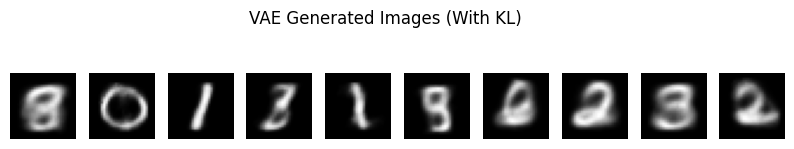

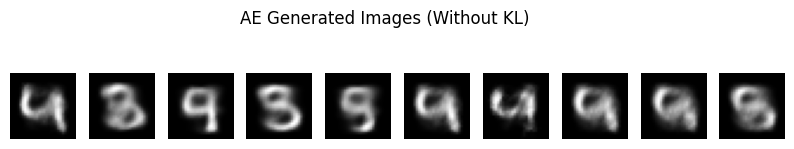

In [ ]:
def show_images(samples, title):
    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(samples[i].view(28, 28).cpu(), cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_images(samples_vae, "VAE Generated Images (With KL)")
show_images(samples_ae, "AE Generated Images (Without KL)")


## LATENT SPACE VISUALIZATION

Latent Space WITH KL Divergence

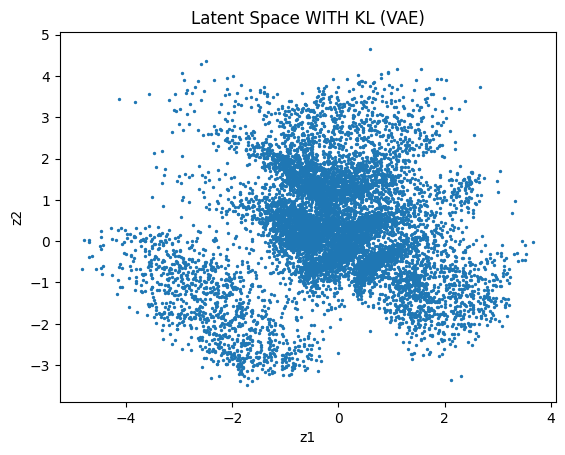

In [ ]:
latents_vae = []

model.eval()
with torch.no_grad():
    for data, _ in test_loader:
        data = data.view(-1, 784).to(device)
        mu, _ = model.encode(data)
        latents_vae.append(mu)

latents_vae = torch.cat(latents_vae).cpu()
plt.scatter(latents_vae[:, 0], latents_vae[:, 1], s=2)
plt.title("Latent Space WITH KL (VAE)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()


Latent Space WITHOUT KL Divergence

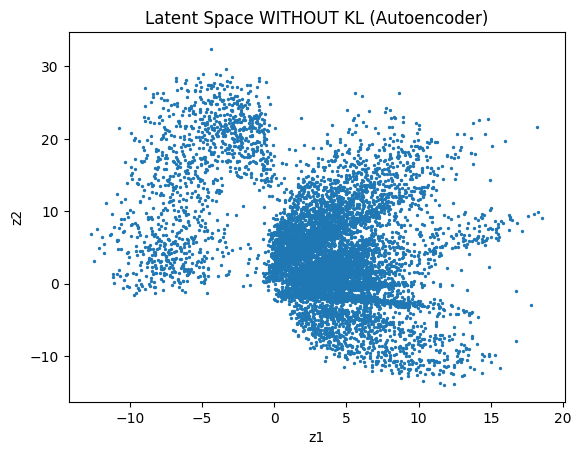

In [ ]:
latents_ae = []

model_ae.eval()
with torch.no_grad():
    for data, _ in test_loader:
        data = data.view(-1, 784).to(device)
        mu, _ = model_ae.encode(data)
        latents_ae.append(mu)

latents_ae = torch.cat(latents_ae).cpu()
plt.scatter(latents_ae[:, 0], latents_ae[:, 1], s=2)
plt.title("Latent Space WITHOUT KL (Autoencoder)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 100

model.train()
for epoch in range(epochs):
    total_loss = 0
    for data, _ in train_loader:
        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = vae_loss(recon, data, mu, logvar)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"[VAE] Epoch {epoch+1}, Loss: {total_loss / len(train_dataset):.4f}")

[VAE] Epoch 1, Loss: 151.4546
[VAE] Epoch 2, Loss: 151.1444
[VAE] Epoch 3, Loss: 150.8677
[VAE] Epoch 4, Loss: 150.5675
[VAE] Epoch 5, Loss: 150.3790
[VAE] Epoch 6, Loss: 150.1690
[VAE] Epoch 7, Loss: 149.9658
[VAE] Epoch 8, Loss: 149.7996
[VAE] Epoch 9, Loss: 149.5960
[VAE] Epoch 10, Loss: 149.3877
[VAE] Epoch 11, Loss: 149.2819
[VAE] Epoch 12, Loss: 149.0500
[VAE] Epoch 13, Loss: 148.8938
[VAE] Epoch 14, Loss: 148.7600
[VAE] Epoch 15, Loss: 148.6241
[VAE] Epoch 16, Loss: 148.4782
[VAE] Epoch 17, Loss: 148.2997
[VAE] Epoch 18, Loss: 148.1809
[VAE] Epoch 19, Loss: 148.0568
[VAE] Epoch 20, Loss: 147.9385
[VAE] Epoch 21, Loss: 147.8136
[VAE] Epoch 22, Loss: 147.6734
[VAE] Epoch 23, Loss: 147.5848
[VAE] Epoch 24, Loss: 147.4868
[VAE] Epoch 25, Loss: 147.3125
[VAE] Epoch 26, Loss: 147.2578
[VAE] Epoch 27, Loss: 147.1404
[VAE] Epoch 28, Loss: 147.0374
[VAE] Epoch 29, Loss: 146.9599
[VAE] Epoch 30, Loss: 146.8863
[VAE] Epoch 31, Loss: 146.7394
[VAE] Epoch 32, Loss: 146.6660
[VAE] Epoch 33, L

In [ ]:
model.eval()
with torch.no_grad():
    z = torch.randn(10, 2).to(device)
    samples_vae = model.decode(z)

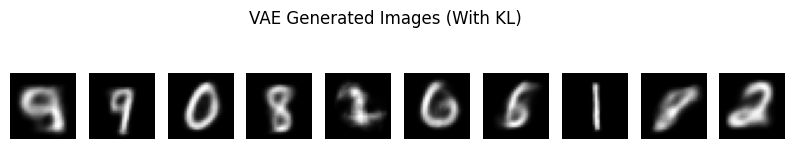

In [ ]:
def show_images(samples, title):
    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(samples[i].view(28, 28).cpu(), cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_images(samples_vae, "VAE Generated Images (With KL)")

In [ ]:
import os

os.makedirs("outputs/vae_images", exist_ok=True)
os.makedirs("outputs/ae_images", exist_ok=True)

print("Output folders created")


Output folders created


In [ ]:
from torchvision.utils import save_image

model.eval()

num_images = 50  # you can change this
with torch.no_grad():
    z = torch.randn(num_images, 2).to(device)
    generated = model.decode(z)
    generated = generated.view(-1, 1, 28, 28)

    for i in range(num_images):
        save_image(
            generated[i],
            f"outputs/vae_images/vae_image_{i+1}.png"
        )

print(f"{num_images} VAE images saved in outputs/vae_images/")


50 VAE images saved in outputs/vae_images/


In [ ]:
model_ae.eval()

num_images = 50
with torch.no_grad():
    z = torch.randn(num_images, 2).to(device)
    generated = model_ae.decode(z)
    generated = generated.view(-1, 1, 28, 28)

    for i in range(num_images):
        save_image(
            generated[i],
            f"outputs/ae_images/ae_image_{i+1}.png"
        )

print(f"{num_images} AE images saved in outputs/ae_images/")


50 AE images saved in outputs/ae_images/


In [ ]:
import shutil

shutil.make_archive(
    "vae_generated_images",
    "zip",
    "outputs/vae_images"
)

shutil.make_archive(
    "ae_generated_images",
    "zip",
    "outputs/ae_images"
)

print("ZIP files created")


ZIP files created
